In [46]:
# with the feedback added 
import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os
from torchdiffeq import odeint

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

def simulate_coupled_oscillators(T=4, dt=1/100, alpha=1.0, omega1=5.01, omega2=5.1,
                                  A_init=0.0001, theta_init=np.pi, n=1.0,
                                  r1_init=1.0, phi1_init=0.0,
                                  r2_init=1.0, phi2_init=0.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = r1_init, r2_init, phi1_init, phi2_init
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1   = alpha * r1 - r1**3 + coupling12
        dr2   = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        r1   += dr1   * dt
        r2   += dr2   * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    final_state = (r1, phi1, r2, phi2)
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1),
                     R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1), final_state

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total_oscillators = num_regions * osc_per_region
    freqs_hz = np.random.uniform(low, high, total_oscillators)
    return 2 * np.pi * freqs_hz

def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            start_i, end_i = i * osc_per_region, (i + 1) * osc_per_region
            start_j, end_j = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[start_i:end_i, start_j:end_j] = intra_value
            else:
                rand_block = np.random.rand(osc_per_region, osc_per_region)
                rand_block *= Sc_region[i, j] / (rand_block.sum() + 1e-9)
                Sc_full[start_i:end_i, start_j:end_j] = rand_block
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full

def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

def train_heart_model(ecg_signal, device, time_sec):

    model = HeartModel().to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=500
    )

    criterion = nn.MSELoss()

    sim_input_np, _ = simulate_coupled_oscillators(T=time_sec)  # ← unpack tuple
    sim_input = torch.tensor(sim_input_np, dtype=torch.float32).to(device)  # ← separate line

    target = torch.tensor(
        ecg_signal[::10],
        dtype=torch.float32
    ).unsqueeze(1).to(device)

    losses = []

    for epoch in range(4000):
        pred = model(sim_input)
        loss = criterion(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch+1) % 2500 == 0:
            print(epoch+1, loss.item())

    return model, losses

def train_mlp_on_frozen_brain(
        trained_heart_model,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_function,
        t,
        device,t_sec):

    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=50,
        N_VNS=18,
        hidden_dim=64,
        output_dim=N,
        device=device
    ).to(device)

    optimizer = torch.optim.Adam(
        ecg_to_osc_mlp.parameters(),
        lr=5e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=10,
        threshold=1e-3,
        cooldown=5,
        min_lr=1e-5
    )

    criterion = CorrelationLoss()

    with torch.no_grad():
        sim_input_np, _ = simulate_coupled_oscillators(T=t_sec, dt=0.01)  
        sim_input = torch.tensor(sim_input_np, dtype=torch.float32).to(device)
        hidden_repr = trained_heart_model.get_features(sim_input)  

    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []
    D_full_train = D_function(t)

    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_full=D_full_train,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=None,
        fs=100,
        fixed_params=initial_brain_params,
        device=device
    )

    for epoch in range(100):

        raw_drive = ecg_to_osc_mlp(hidden_repr)  
        brain_drive_full = (raw_drive)
        model.ode_func.brain_drive_full = brain_drive_full

        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params['r'],
            initial_brain_params['phi'],
            t,
            use_adjoint=False
        )

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        settle = int(0.1 * model.ode_func.fs)   # ignore first 300 ms
        pred = P_out[settle:]
        target = D_true[settle:]

        corr_loss = criterion(pred, target)
        mse_loss = torch.mean((pred - target) ** 2)

        loss = mse_loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch {epoch+1}, "
                f"Loss: {loss.item():.6f}, "
                f"LR: {current_lr:.3e}"
            )


    return ecg_to_osc_mlp, losses


# classes 
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),       
            nn.Linear(hidden_dim, feature_dim),
            nn.SiLU(),       
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)
    
    def get_features(self, x):
        return self.feature_extractor(x)
    
class BrainToHeartMLP(nn.Module):
    """
    Brain oscillators → MLP → OscillatorLayer → heart drive
    """
    def __init__(self, brain_dim, N_heart_osc, hidden_dim=64, device="cuda"):
        super().__init__()

        self.pre_osc = nn.Sequential(
            nn.Linear(brain_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, N_heart_osc)
        )

        self.osc_layer = OscillatorLayer(N_osc=N_heart_osc, fs=100, device=device)

        self.post_osc = nn.Sequential(
            nn.Linear(N_heart_osc, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)  # scalar heart drive
        )

    def forward(self, brain_state):
        x = self.pre_osc(brain_state)
        osc_hidden = self.osc_layer(x)
        heart_drive = self.post_osc(osc_hidden)
        return heart_drive
    
class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta, fs=100, device="cpu"):  # ✅ fs added
        super().__init__()
        self.N_osc = N_osc
        self.fs = fs          # ✅ set here instead of patched externally
        self.mu = mu
        self.k = k

        self.omega=omega
        self.register_buffer("C", C)
        self.register_buffer("theta", theta)
        self.r_min = 0.001
        self.r_max = 3.0
        self.phase_clip = 2 * np.pi
        self.input_f = None

    def forward(self, t, state):
        N = self.N_osc
        r   = state[:N]
        phi = state[N:2*N]

        t_idx = torch.clamp(
            (t * self.fs).long(),
            0,
            self.input_f.shape[0] - 1
        )

        input_f = 0.05 * self.input_f[t_idx]  # ✅ shape (N,) — removed unsqueeze(-1)

        # ✅ clamp omega for numerical stability
        omega = torch.clamp(self.omega, 2 * np.pi * 1.0, 2 * np.pi * 20.0)

        r_safe = torch.clamp(r, self.r_min, self.r_max)

        # ✅ explicit 2D broadcasting — clearer than .T on a 1D tensor
        omega_i = omega.unsqueeze(1)    # (N, 1)
        omega_j = omega.unsqueeze(0)    # (1, N)
        phi_i   = phi.unsqueeze(1)      # (N, 1)
        phi_j   = phi.unsqueeze(0)      # (1, N)
        r_safe_i = r_safe.unsqueeze(1)  # (N, 1)
        r_safe_j = r_safe.unsqueeze(0)  # (1, N)

        phase_term = torch.clamp(
            phi_j / omega_j - phi_i / omega_i + self.theta / (omega_i * omega_j),
            -self.phase_clip,
            self.phase_clip
        )  # (N, N)

        coupling_r   = self.k * torch.sum(self.C * r_safe_j * torch.cos(phase_term), dim=1)  # (N,)
        coupling_phi = self.k * torch.sum(self.C * (r_safe_j / r_safe_i) * torch.sin(phase_term), dim=1)  # (N,)

        dr_dt   = (self.mu - r_safe ** 2) * r_safe + coupling_r + input_f  # (N,)
        dphi_dt = omega + coupling_phi                                       # (N,)

        return torch.cat([dr_dt, dphi_dt])  # (2N,) — ✅ no .flatten() needed, already 1D


class OscillatorLayer(nn.Module):
    def __init__(self, N_osc=16, fs=100, device="cpu",
                 coupling_sparsity=0.3, seed=42):
        super().__init__()

        self.N_osc = N_osc
        self.fs = fs
        self.dt = 1.0 / fs

        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0

        # ✅ omega is now a learnable parameter
        self.omega_param = nn.Parameter(2 * torch.pi * freqs)
        # leave mu and k as buffers — stable fixed dynamics
        self.register_buffer("mu_param", torch.tensor(1.0, device=device))
        self.register_buffer("k_param",  torch.tensor(0.05, device=device))

        mask  = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)
        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.register_buffer("C_buffer",     C_val * mask.float())
        self.register_buffer("theta_buffer", torch.zeros(N_osc, N_osc, device=device))

        self.ode_func = OscillatorODEFunc(
            N_osc=N_osc,
            mu=self.mu_param,
            k=self.k_param,
            omega=self.omega_param,
            C=self.C_buffer,
            theta=self.theta_buffer,
            fs=fs,           # ✅ passed in constructor
            device=device
        )

        # ✅ better initial r — avoids lower clamp boundary
        self.register_buffer("initial_r",   torch.ones(N_osc, device=device) * 0.5)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))

        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features):  # input_features: (T, N_osc)
        T = input_features.shape[0]

        # ✅ fs no longer needs to be set here — it's fixed at init
        self.ode_func.input_f = input_features

        y0 = torch.cat([self.initial_r, self.initial_phi])  # (2N,)

        t_eval = torch.arange(0, T, device=input_features.device, dtype=torch.float32) / self.fs

        sol = odeint(self.ode_func, y0, t_eval, method="rk4")  # (T, 2N)

        r   = torch.clamp(sol[:, :self.N_osc],  self.r_min, self.r_max)
        phi = sol[:, self.N_osc:]

        return (r * torch.cos(phi))  # (T, N_osc)


class ECGToOscillatorMLP(nn.Module):
    """ECG → MLP → OscillatorLayer → MLP → Brain drive [N]"""
    def __init__(self, ecg_dim=50, N_VNS=18, hidden_dim=64, output_dim=16, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS,
            fs=100,
            device=device,
            coupling_sparsity=0.3,
            seed=42
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, ecg_features):  # (T, ecg_dim)
        # ✅ only normalize when we have multiple timesteps — avoids std=0 crash
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)

        if ecg_features.shape[0] > 1:
            ecg_features = (ecg_features - ecg_features.mean(dim=0, keepdim=True)) / (
                ecg_features.std(dim=0, keepdim=True) + 1e-6
            )

        pre        = self.pre_osc(ecg_features)   # (T, N_VNS)
        osc_hidden = self.osc_layer(pre)           # (T, N_VNS)
        brain_drive = self.post_osc(osc_hidden)    # (T, output_dim)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)
        return brain_drive

class ODEFuc(nn.Module):
    def __init__(self, mu, D_full, N, Sc,
                 omega0, alpha0, theta0,
                 brain_drive_full=None,
                 fs=100,
                 fixed_params=None):

        super().__init__()
        self.mu = mu
        self.register_buffer("D_full", torch.tensor(D_full, dtype=torch.float32))
        self.N = N
        self.fs = fs
        self.register_buffer('Sc', torch.tensor(Sc, dtype=torch.float32))
        self.brain_drive_full = brain_drive_full
        self.fixed_params = fixed_params

        if self.fixed_params is not None:
            # Stage 2 — freeze everything
            self.register_buffer('theta_fixed', torch.tensor(fixed_params['theta'], dtype=torch.float32))
            self.register_buffer('omega_fixed', torch.tensor(fixed_params['omega'], dtype=torch.float32))
            self.register_buffer('alpha_fixed', torch.tensor(fixed_params['alpha'], dtype=torch.float32))
        else:
            # Stage 1 — omega, alpha, theta are learnable parameters
            self.omega_param = nn.Parameter(torch.tensor(omega0, dtype=torch.float32))
            self.alpha_param = nn.Parameter(torch.tensor(alpha0, dtype=torch.float32))
            self.theta_param = nn.Parameter(torch.tensor(theta0, dtype=torch.float32))

    def forward(self, t, state):
        N = self.N

        if self.fixed_params is not None:
            r   = state[:N]
            phi = state[N:2*N]
            omega = self.omega_fixed
            alpha = self.alpha_fixed
            theta = self.theta_fixed
        else:
            # Only r and phi are in the ODE state now
            r   = state[:N]
            phi = state[N:2*N]
            omega = self.omega_param
            alpha = self.alpha_param
            theta = self.theta_param

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r     = torch.clamp(r, 1e-1, 4.0)
        alpha = torch.clamp(alpha, -3.0, 3.0)

        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]),
            -1e2, 1e2
        )

        t_idx_D = torch.clamp((t * self.fs).long(), 0, self.D_full.shape[0] - 1)
        D = self.D_full[t_idx_D]

        P = torch.sum(alpha * r * torch.cos(phi % (2 * np.pi)))
        e = D - P

        if self.brain_drive_full is not None:
            t_idx_drive = torch.clamp((t * self.fs).long(), 0, self.brain_drive_full.shape[0] - 1)
            ecg_input = self.brain_drive_full[t_idx_drive]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        coupling_r   = torch.sum(self.Sc * r[None, :] * torch.cos(phase_diff), dim=1)
        coupling_phi = torch.sum(self.Sc * (r[None, :] / r[:, None]) * torch.sin(phase_diff), dim=1)

        drdt   = (self.mu - r**2) * r + coupling_r   + e * torch.cos(phi) + ecg_input
        dphidt = omega_safe + coupling_phi - (e / r) * torch.sin(phi) - (ecg_input/r)*torch.sin(phi) # changed to correct phase 

        # Only r and phi are integrated — omega/alpha/theta updated by backprop
        return torch.cat([drdt.flatten(), dphidt.flatten()])


class TorchRevHopfNetwork:
    def __init__(self, mu, D_full, N, Sc,
                 omega0=None, alpha0=None, theta0=None,
                 brain_drive_full=None,
                 fs=100,
                 fixed_params=None,
                 device="cuda",
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0):

        self.device = torch.device(device)
        self.N = N

        self.ode_func = ODEFuc(
            mu=mu,
            D_full=D_full,
            N=N,
            Sc=Sc,
            omega0=omega0,
            alpha0=alpha0,
            theta0=theta0,
            brain_drive_full=brain_drive_full,
            fs=fs,
            fixed_params=fixed_params
        ).to(self.device)

    def solve(self, r0, phi0, t_eval, use_adjoint=False):
        y0 = torch.tensor(
            np.concatenate([r0, phi0]),
            device=self.device,
            dtype=torch.float32
        )

        t_eval_tensor = torch.tensor(t_eval, device=self.device, dtype=torch.float32)

        if use_adjoint:
            sol = odeint_adjoint(
                self.ode_func, y0, t_eval_tensor,
                method="rk4",
                adjoint_params=tuple(self.ode_func.parameters())
            )
        else:
            sol = odeint(self.ode_func, y0, t_eval_tensor, method="rk4")

        N = self.N
        r   = sol[:, :N]
        phi = sol[:, N:2*N]

        # Return omega/alpha/theta expanded to (T, N) for downstream compatibility
        if self.ode_func.fixed_params is not None:
            omega = self.ode_func.omega_fixed.unsqueeze(0).expand(sol.shape[0], N)
            alpha = self.ode_func.alpha_fixed.unsqueeze(0).expand(sol.shape[0], N)
            theta = self.ode_func.theta_fixed.unsqueeze(0).expand(sol.shape[0], N, N)
        else:
            omega = self.ode_func.omega_param.unsqueeze(0).expand(sol.shape[0], N)
            alpha = self.ode_func.alpha_param.unsqueeze(0).expand(sol.shape[0], N)
            theta = self.ode_func.theta_param.unsqueeze(0).expand(sol.shape[0], N, N)

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)
        return r, phi, theta, omega, alpha, rcos_phi


def pre_train_brain_model(eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Stage 1: Brain Pre-training (backprop) ---")
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 4
    N = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)
    Sc_reduced_osc = Sc_reduced_osc * 10.0 
    print("N:", N)
    print("N_reduced_regions:", N_reduced_regions)
    print("Sc_reduced_osc sparsity:", (Sc_reduced_osc == 0).mean())
    print("Sc_reduced_osc max:", Sc_reduced_osc.max())
    print("Sc_reduced_osc mean nonzero:", Sc_reduced_osc[Sc_reduced_osc > 0].mean())

    omega_full = get_random_frequencies(68, osc_per_region, low=1, high=20, seed=42)
    omega0 = np.concatenate([omega_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices])
    alpha0 = np.ones(N) * (1.0 / np.sqrt(N))
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T

    r0   = np.ones(N)
    phi0 = np.zeros(N)

    D_full_train = D_function(t)

    model = TorchRevHopfNetwork(
        mu=1.0,
        D_full=D_full_train,
        N=N,
        Sc=Sc_reduced_osc,
        omega0=omega0,
        alpha0=alpha0,
        theta0=theta0,
        fs=100,
        fixed_params=None,   # None = Stage 1, params are learnable
        device=device
    )

    optimizer = torch.optim.Adam([
        {'params': [model.ode_func.omega_param], 'lr': 1e-2},
        {'params': [model.ode_func.alpha_param], 'lr': 1e-2},
        {'params': [model.ode_func.theta_param], 'lr': 1e-3},  # theta slower — it's N×N
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-5
    )

    criterion = CorrelationLoss()
    D_true = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    settle = 10
    losses = []

    for epoch in range(160):
        # No torch.no_grad() — we need gradients through the ODE
        r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, t, use_adjoint=False)

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        corr_loss = criterion(P_out[settle:], D_true[settle:])
        P_std_val = torch.std(P_out[settle:])
        D_std_val = torch.std(D_true[settle:])
        scale_loss = (P_std_val / D_std_val - 1.0) ** 2
        alpha_penalty = torch.mean(torch.relu(0.3 - model.ode_func.alpha_param ** 2))
        loss = corr_loss + 0.1 * scale_loss + 0.2 * alpha_penalty
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [model.ode_func.omega_param,
             model.ode_func.alpha_param,
             model.ode_func.theta_param],
            max_norm=1.0
        )
        optimizer.step()

        # Warm-start r and phi only — omega/alpha/theta are now parameters
        with torch.no_grad():
            r0   = r[-1].cpu().numpy()
            phi0 = (phi[-1].cpu().numpy()) % (2 * np.pi)

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            P_scale = torch.std(P_out[settle:]).item()
            D_scale = torch.std(D_true[settle:]).item()
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Brain Epoch {epoch+1}/300, Loss: {loss.item():.6f} | "
                  f"P_std: {P_scale:.4f} D_std: {D_scale:.4f} | LR: {current_lr:.2e}")
        
        scheduler.step(loss.item())

    final_params = {
        'r':     r[-1].detach().cpu().numpy(),
        'phi':   (phi[-1].detach().cpu().numpy()) % (2 * np.pi),
        'theta': model.ode_func.theta_param.detach().cpu().numpy(),
        'omega': model.ode_func.omega_param.detach().cpu().numpy(),
        'alpha': model.ode_func.alpha_param.detach().cpu().numpy()
    }
    return final_params, Sc_reduced_osc, N, losses
class CorrelationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):

        pred = pred - torch.mean(pred)
        target = target - torch.mean(target)

        numerator = torch.sum(pred * target)

        denominator = torch.sqrt(
            torch.sum(pred ** 2) * torch.sum(target ** 2) + self.eps
        )

        corr = numerator / denominator

        loss = 1 - corr
        return loss
    


In [47]:

file_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
raw = mne.io.read_raw_fif(file_raw, preload=True)

mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
sc_matrix = sc_data["sc"]

max_val = np.max(sc_matrix)
Sw_all = (sc_matrix / max_val) * 0.2
percentile = 60
thr = np.percentile(Sw_all, percentile)

Sw_sparse = Sw_all.copy()
Sw_sparse[Sw_sparse < thr] = 0
non_zero_indices_per_row = [
    np.nonzero(Sw_sparse[i])[0]
    for i in range(Sw_sparse.shape[0])
]

fs_raw = 1000
train_sec = 10
test_sec = 5

start_idx = 2000
train_samples = train_sec * fs_raw
test_samples = test_sec * fs_raw

train_slice = slice(start_idx, start_idx + train_samples)
test_slice  = slice(start_idx + train_samples,
                    start_idx + train_samples + test_samples)

# ECG
ecg_train = -raw[322, train_slice][0][0]
ecg_test  = -raw[322, test_slice][0][0]

# EEG
eeg_train = mat['Value'][:, train_slice]
eeg_test  = mat['Value'][:, test_slice]

# ===============================
# PREPROCESS
# ===============================

ecg_train_processed = preprocess_signal(ecg_train, fs=1000, lowcut=1.5, highcut=20)
ecg_test_processed  = preprocess_signal(ecg_test,  fs=1000, lowcut=1.5, highcut=20)

eeg_train_processed = np.array([
    preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20)
    for row in eeg_train
])

eeg_test_processed = np.array([
    preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20)
    for row in eeg_test
])


target_idx = 1

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Using device: {device} ---")

fs_model = 100

t_train = np.arange(0, train_sec, 1/fs_model)
t_test  = np.arange(0, test_sec, 1/fs_model)

target_train = eeg_train_processed[target_idx, ::10]
target_test  = eeg_test_processed[target_idx, ::10]

D_train = interp1d(t_train, target_train,
                   kind='linear',
                   bounds_error=False,
                   fill_value=0.0)

D_test = interp1d(t_test, target_test,
                  kind='linear',
                  bounds_error=False,
                  fill_value=0.0)


Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...
--- Using device: cuda ---


2500 0.5267760157585144


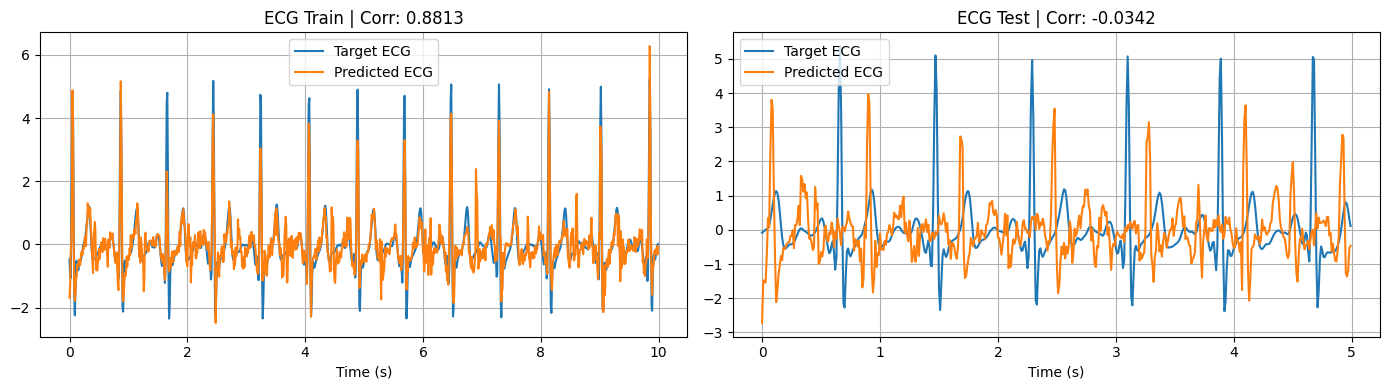

ECG Train Corr: 0.8813
ECG Test  Corr: -0.0342


In [48]:
trained_heart_model, heart_losses = train_heart_model(
    ecg_train_processed,
    device, train_sec
)

with torch.no_grad():
    sim_check_np, osc_final = simulate_coupled_oscillators(T=train_sec, dt=1/fs_model)
    sim_check = torch.tensor(sim_check_np, dtype=torch.float32).to(device)
    ecg_check_train = trained_heart_model(sim_check).cpu().numpy().flatten()

    r1_end, phi1_end, r2_end, phi2_end = osc_final  # ← only once
    phi1_end = phi1_end % (2 * np.pi)
    phi2_end = phi2_end % (2 * np.pi)
    phi2_end = phi1_end 

    sim_check_test_np, _ = simulate_coupled_oscillators(
        T=test_sec, dt=1/fs_model,
        r1_init=r1_end, phi1_init=phi1_end,
        r2_init=r2_end, phi2_init=phi2_end
    )
    sim_check_test = torch.tensor(sim_check_test_np, dtype=torch.float32).to(device)
    ecg_check_test = trained_heart_model(sim_check_test).cpu().numpy().flatten()

target_ecg_check_train = ecg_train_processed[::10]
target_ecg_check_test  = ecg_test_processed[::10]

min_train = min(len(target_ecg_check_train), len(ecg_check_train))
min_test  = min(len(target_ecg_check_test),  len(ecg_check_test))

t_check_train = np.arange(min_train) / fs_model
t_check_test  = np.arange(min_test)  / fs_model

corr_train = np.corrcoef(target_ecg_check_train[:min_train], ecg_check_train[:min_train])[0,1]
corr_test  = np.corrcoef(target_ecg_check_test[:min_test],   ecg_check_test[:min_test])[0,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t_check_train, target_ecg_check_train[:min_train], label="Target ECG")
axes[0].plot(t_check_train, ecg_check_train[:min_train],        label="Predicted ECG")
axes[0].set_title(f"ECG Train | Corr: {corr_train:.4f}")
axes[0].set_xlabel("Time (s)"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_check_test, target_ecg_check_test[:min_test], label="Target ECG")
axes[1].plot(t_check_test, ecg_check_test[:min_test],        label="Predicted ECG")
axes[1].set_title(f"ECG Test | Corr: {corr_test:.4f}")
axes[1].set_xlabel("Time (s)"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"ECG Train Corr: {corr_train:.4f}")
print(f"ECG Test  Corr: {corr_test:.4f}")

In [ ]:

final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_train_processed,
    Sw_all,
    target_idx,
    non_zero_indices_per_row,
    t_train,
    D_train,
    device
)



--- Stage 1: Brain Pre-training (backprop) ---
N: 72
N_reduced_regions: 18
Sc_reduced_osc sparsity: 0.026234567901234566
Sc_reduced_osc max: 0.10265035029973238
Sc_reduced_osc mean nonzero: 0.004200402531583816
Brain Epoch 10/300, Loss: 0.909420 | P_std: 0.7092 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 20/300, Loss: 0.806904 | P_std: 0.7483 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 30/300, Loss: 0.753643 | P_std: 0.6776 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 40/300, Loss: 0.667097 | P_std: 0.6693 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 50/300, Loss: 0.652332 | P_std: 0.6679 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 60/300, Loss: 0.631371 | P_std: 0.6763 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 70/300, Loss: 0.614656 | P_std: 0.6980 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 80/300, Loss: 0.599652 | P_std: 0.7232 D_std: 0.9895 | LR: 1.00e-02
Brain Epoch 90/300, Loss: 0.603166 | P_std: 0.7370 D_std: 0.9895 | LR: 1.00e-02


In [ ]:
trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
    trained_heart_model,
    final_brain_params,
    Sc_reduced_osc,
    N,
    D_train,
    t_train,
    device,train_sec
)


--- Stage 2: ECG → OscillatorLayer → Brain Training ---
Epoch 20, Loss: 0.388351, LR: 5.000e-03
Epoch 40, Loss: 0.169002, LR: 5.000e-03
Epoch 60, Loss: 0.076813, LR: 5.000e-03
Epoch 80, Loss: 0.046211, LR: 5.000e-03
Epoch 100, Loss: 0.019412, LR: 5.000e-03



===== PERFORMANCE (First 0.1s Ignored) =====

ECG Train | MSE: 0.0030 | Corr: 0.9981
ECG Test  | MSE: 3.7700  | Corr: -0.0414

EEG Train | MSE: 0.0194 | Corr: 0.9899
EEG Test  | MSE: 2.4834  | Corr: -0.1719
Best lag: 500.0 ms | Phase-corrected corr: -0.0585


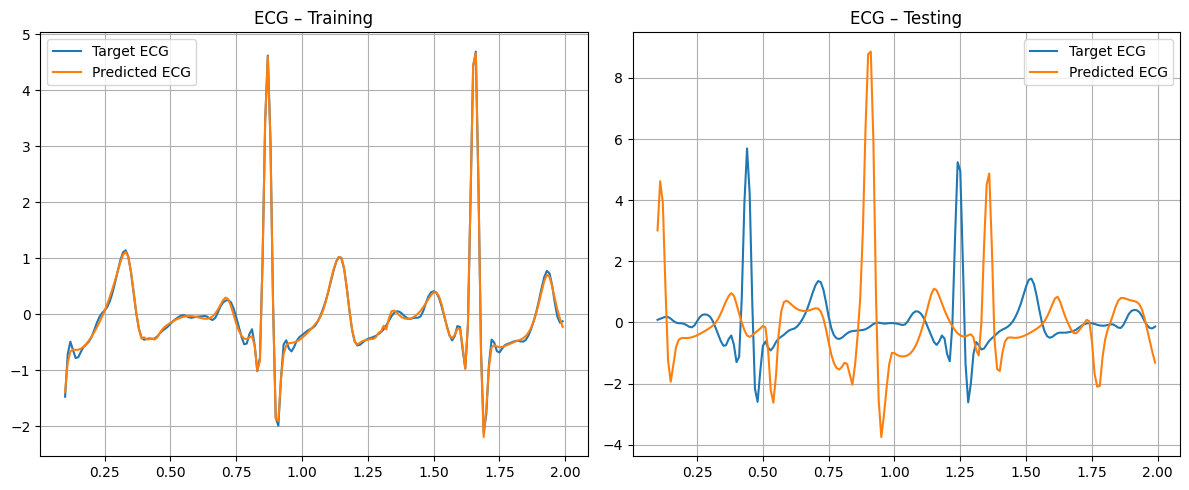

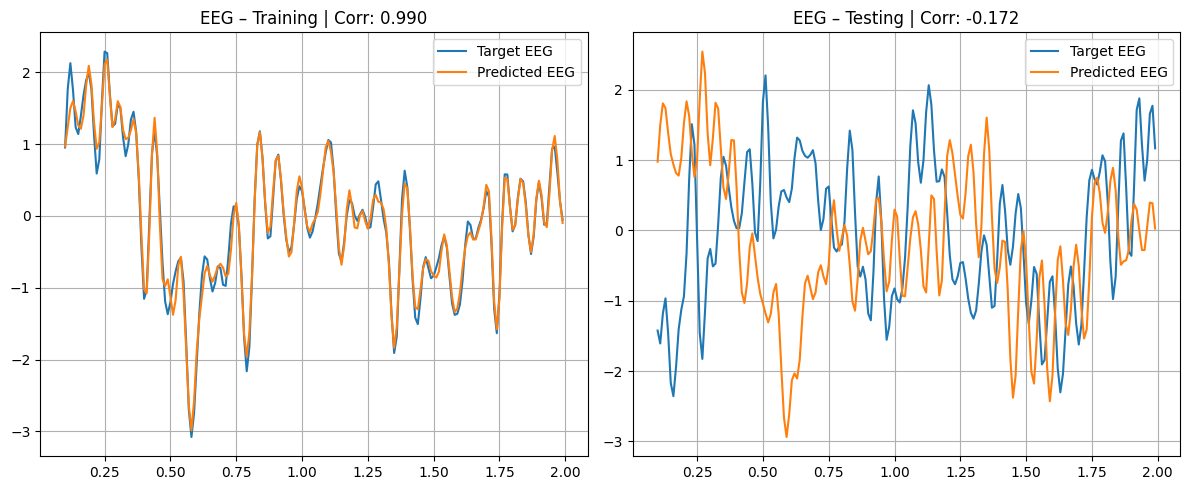

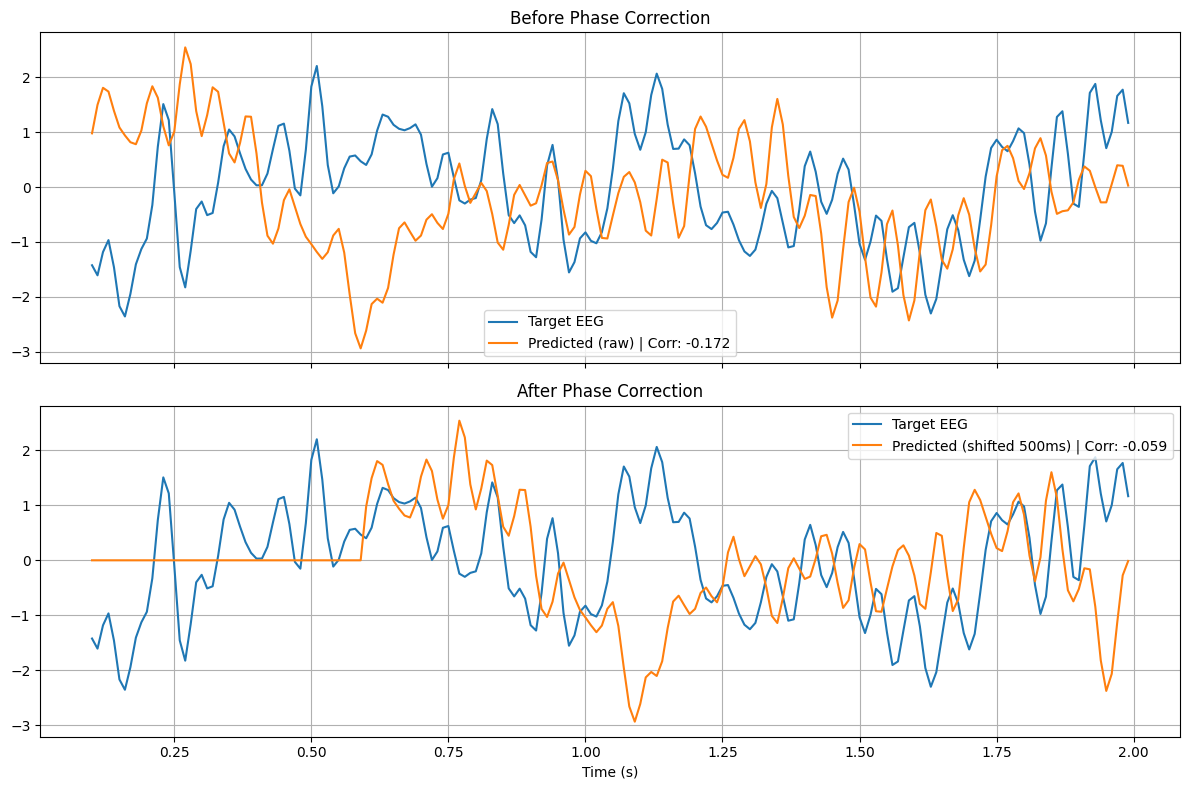

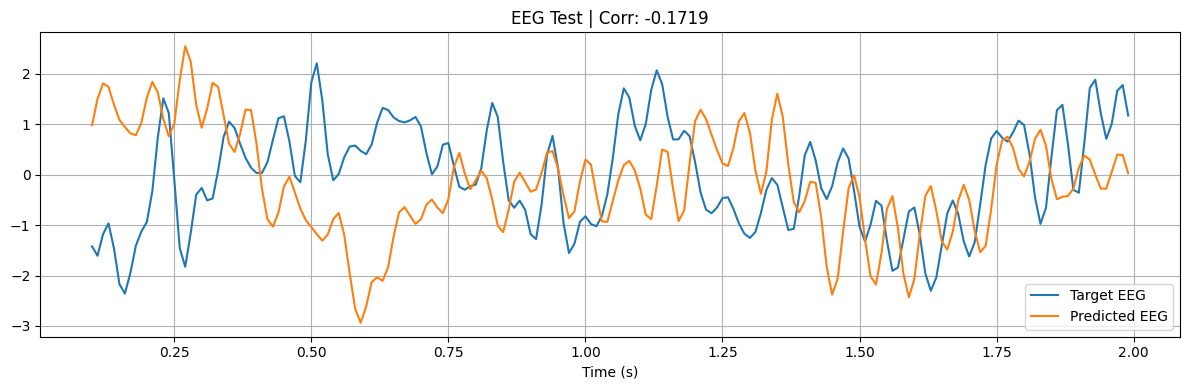

In [ ]:
trained_heart_model.eval()
trained_mlp_model.eval()

# -------- Oscillator simulations — chained across train/test --------
sim_train_np, osc_train_final = simulate_coupled_oscillators(T=train_sec, dt=1/fs_model)
sim_train = torch.tensor(sim_train_np, dtype=torch.float32).to(device)

r1_end, phi1_end, r2_end, phi2_end = osc_train_final
sim_test_np, _ = simulate_coupled_oscillators(
    T=test_sec, dt=1/fs_model,
    r1_init=r1_end, phi1_init=phi1_end,
    r2_init=r2_end, phi2_init=phi2_end
)
sim_test = torch.tensor(sim_test_np, dtype=torch.float32).to(device)

# -------- ECG TRAIN --------
with torch.no_grad():
    ecg_pred_train = trained_heart_model(sim_train).cpu().numpy().flatten()
target_ecg_train = ecg_train_processed[::10]

# -------- ECG TEST --------
with torch.no_grad():
    ecg_pred_test = trained_heart_model(sim_test).cpu().numpy().flatten()
target_ecg_test = ecg_test_processed[::10]

# -------- EEG TRAIN + extract final state for warm-start --------
with torch.no_grad():
    hidden_train = trained_heart_model.get_features(sim_train)
    brain_drive_train = trained_mlp_model(hidden_train).detach()

    model_train = TorchRevHopfNetwork(
        mu=1.0, D_full=D_train(t_train), N=N,
        Sc=Sc_reduced_osc, brain_drive_full=brain_drive_train,
        fs=100, fixed_params=final_brain_params, device=device
    )

    r_tr, phi_tr, theta_tr, omega_tr, alpha_tr, _ = model_train.solve(
        final_brain_params['r'],
        final_brain_params['phi'],
        t_train,
        use_adjoint=False
    )

    P_train = torch.sum(
        alpha_tr * r_tr * torch.cos(phi_tr),
        dim=1
    ).cpu().numpy()

    # warm-start: carry final train state into test
    test_init_params = final_brain_params.copy()
    test_init_params['r']   = r_tr[-1].cpu().numpy()
    test_init_params['phi'] = phi_tr[-1].cpu().numpy()

# -------- EEG TEST — warm-started --------
with torch.no_grad():
    hidden_test = trained_heart_model.get_features(sim_test)
    brain_drive_test = trained_mlp_model(hidden_test)

    model_test = TorchRevHopfNetwork(
        mu=1.0, D_full=D_test(t_test), N=N,
        Sc=Sc_reduced_osc, brain_drive_full=brain_drive_test,
        fs=fs_model, fixed_params=final_brain_params, device=device
    )

    r_te, phi_te, theta_te, omega_te, alpha_te, _ = model_test.solve(
        test_init_params['r'],
        test_init_params['phi'],
        t_test,
        use_adjoint=False
    )

    P_test = torch.sum(
        alpha_te * r_te * torch.cos(phi_te),
        dim=1
    ).cpu().numpy()

# -------- METRICS --------
def metrics(y_true, y_pred):
    mse  = np.mean((y_true - y_pred) ** 2)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    return mse, corr

def phase_corrected_corr(y_true, y_pred, max_lag_sec=0.5, fs=100):
    from scipy.signal import correlate
    max_lag = int(max_lag_sec * fs)
    cc = correlate(y_true, y_pred, mode='full')
    lags = np.arange(-len(y_true) + 1, len(y_true))
    best_lag = int(np.clip(lags[np.argmax(cc)], -max_lag, max_lag))
    if best_lag > 0:
        y_shifted = np.concatenate([np.zeros(best_lag), y_pred[:-best_lag]])
    elif best_lag < 0:
        y_shifted = np.concatenate([y_pred[-best_lag:], np.zeros(-best_lag)])
    else:
        y_shifted = y_pred
    corr = np.corrcoef(y_true, y_shifted)[0, 1]
    print(f"Best lag: {best_lag/fs*1000:.1f} ms | Phase-corrected corr: {corr:.4f}")
    return corr, best_lag, y_shifted

ignore_sec     = 0.1
ignore_samples = int(ignore_sec * fs_model)

mse_ecg_train, corr_ecg_train = metrics(target_ecg_train[ignore_samples:], ecg_pred_train[ignore_samples:])
mse_ecg_test,  corr_ecg_test  = metrics(target_ecg_test[ignore_samples:],  ecg_pred_test[ignore_samples:])

target_eeg_train = D_train(t_train)
target_eeg_test  = D_test(t_test)

mse_eeg_train, corr_eeg_train = metrics(target_eeg_train[ignore_samples:], P_train[ignore_samples:])
mse_eeg_test,  corr_eeg_test  = metrics(target_eeg_test[ignore_samples:],  P_test[ignore_samples:])

print("\n===== PERFORMANCE (First 0.1s Ignored) =====")
print(f"\nECG Train | MSE: {mse_ecg_train:.4f} | Corr: {corr_ecg_train:.4f}")
print(f"ECG Test  | MSE: {mse_ecg_test:.4f}  | Corr: {corr_ecg_test:.4f}")
print(f"\nEEG Train | MSE: {mse_eeg_train:.4f} | Corr: {corr_eeg_train:.4f}")
print(f"EEG Test  | MSE: {mse_eeg_test:.4f}  | Corr: {corr_eeg_test:.4f}")

corr_pc, lag, P_test_shifted = phase_corrected_corr(
    target_eeg_test[ignore_samples:],
    P_test[ignore_samples:],
    fs=fs_model
)

# -------- PLOTS --------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(t_train[ignore_samples:], target_ecg_train[ignore_samples:], label="Target ECG")
axes[0].plot(t_train[ignore_samples:], ecg_pred_train[ignore_samples:],   label="Predicted ECG")
axes[0].set_title("ECG – Training"); axes[0].legend(); axes[0].grid(True)
axes[1].plot(t_test[ignore_samples:], target_ecg_test[ignore_samples:], label="Target ECG")
axes[1].plot(t_test[ignore_samples:], ecg_pred_test[ignore_samples:],   label="Predicted ECG")
axes[1].set_title("ECG – Testing"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(t_train[ignore_samples:], target_eeg_train[ignore_samples:], label="Target EEG")
axes[0].plot(t_train[ignore_samples:], P_train[ignore_samples:],           label="Predicted EEG")
axes[0].set_title(f"EEG – Training | Corr: {corr_eeg_train:.3f}")
axes[0].legend(); axes[0].grid(True)
axes[1].plot(t_test[ignore_samples:], target_eeg_test[ignore_samples:], label="Target EEG")
axes[1].plot(t_test[ignore_samples:], P_test[ignore_samples:],           label="Predicted EEG")
axes[1].set_title(f"EEG – Testing | Corr: {corr_eeg_test:.3f}")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t_test[ignore_samples:], target_eeg_test[ignore_samples:], label="Target EEG")
axes[0].plot(t_test[ignore_samples:], P_test[ignore_samples:],           label=f"Predicted (raw) | Corr: {corr_eeg_test:.3f}")
axes[0].set_title("Before Phase Correction"); axes[0].legend(); axes[0].grid(True)
axes[1].plot(t_test[ignore_samples:], target_eeg_test[ignore_samples:], label="Target EEG")
axes[1].plot(t_test[ignore_samples:], P_test_shifted,                    label=f"Predicted (shifted {lag/fs_model*1000:.0f}ms) | Corr: {corr_pc:.3f}")
axes[1].set_title("After Phase Correction"); axes[1].set_xlabel("Time (s)")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t_test[ignore_samples:], target_eeg_test[ignore_samples:], label="Target EEG")
plt.plot(t_test[ignore_samples:], P_test[ignore_samples:],           label="Predicted EEG")
plt.title(f"EEG Test | Corr: {corr_eeg_test:.4f}")
plt.xlabel("Time (s)"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()